In [78]:
from xaikd import attributors, models, utils
from torch.nn import functional as F
from PIL import Image
from torchvision import transforms as T
import numpy as np
import torch
from matplotlib import pyplot as plt

In [11]:
img = Image.open("../tests/data/castle.jpg")

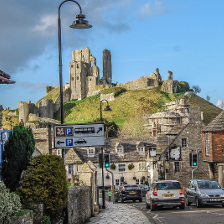

In [12]:
img

In [60]:
input_statistics = [
    [0.485, 0.456, 0.406],
    [0.229, 0.224, 0.225]
]
normalizer = T.Normalize(mean=input_statistics[0], std=input_statistics[1])
transform = T.Compose(
    [
        T.ToTensor(), 
        normalizer
    ]
)

In [61]:
ts_img = transform(img)

In [81]:
model = models.get_trained_model("imagenet-vgg16-tv")

In [63]:
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [110]:
arr_layers = ["features.16", "features.23", "features.30"]

In [116]:
 output, arr_outputs = utils.interceptor.forward_and_intercept_intermediate_layers(
    model, ts_img.unsqueeze(0),
    layers=arr_layers,
    detach_output=False
)

In [119]:
np.argsort(-output.detach().cpu().numpy().squeeze())

array([483, 497, 663, 442, 498, 409, 919, 920, 853, 970, 468, 437, 698,
       557, 892, 762, 458, 743, 972, 624, 656, 682, 839, 863, 884, 538,
       415, 454, 832, 835, 900, 407, 873, 708, 627, 733, 858, 734, 637,
       976, 517, 649, 704, 984, 880, 654, 609, 727, 426, 480, 405, 530,
       460, 860, 975, 668, 825, 500, 494, 829, 757, 888, 412, 664, 571,
       818, 670, 448, 611, 421, 417, 716, 779, 582, 562, 979, 646, 424,
       978, 406, 826, 425, 665, 865, 471, 479, 695, 867, 980, 772, 864,
       982, 288, 447, 475, 511, 718, 671, 436, 449, 781, 632, 791, 531,
       536, 489, 621, 916, 640, 917, 600, 675, 620, 812, 872, 819, 444,
       523, 782, 575, 958, 488, 897, 717, 870, 821, 408, 487, 755, 795,
       879, 555, 706, 882, 660, 350, 707, 569, 628, 817, 833, 553, 603,
       778, 428, 754, 844, 862, 971, 850, 768, 851, 886, 478, 289, 616,
       581,  23, 509, 751, 525, 373, 612, 918, 561, 705, 622, 866, 681,
       855, 625, 788, 898, 902, 667, 874, 807,  24, 463, 723, 73

In [112]:
def explain_and_intercept(model, x, class_ix, arr_layers=arr_layers):
    target = torch.tensor([class_ix])
    
    arr_hooks = []
    try:
        for layer in arr_layers:
            module, hook = utils.interceptor.attach_hook_intercept_layer_output(
                model, layer, should_retain_grad=True, detach_output=False
            )
            
            arr_hooks.append((module, hook))
        

        with  attributors.make_attributor_for(model, input_statistics) as attributor:
            _ = attributor.forward(
                x,
                lambda logits: logits * F.one_hot(target,1000)
            )
            
            
        arr_outputs = []
        for module, _ in arr_hooks:
            act = utils.interceptor.get_output(module)
            rel = act.grad.detach().squeeze().numpy().sum(axis=0)
            arr_outputs.append(rel)
        return arr_outputs
    finally:
        
        for _, hook in arr_hooks:
            hook.remove()
            
explain_and_intercept(model, ts_img.unsqueeze(0), 483, arr_layers=["features.23"])

[array([[ 0.04893683,  0.0423838 ,  0.03238868,  0.00235262,  0.01579896,
          0.04352307,  0.03958061,  0.0308299 ,  0.02726791,  0.0256468 ,
          0.03244954,  0.03290716,  0.06358079,  0.2054775 ],
        [ 0.03152393,  0.02206738,  0.01991002, -0.00061922,  0.01787157,
          0.10214919,  0.02211368,  0.05194648,  0.03320265,  0.01146188,
          0.00971056,  0.00748331,  0.00913628,  0.03169459],
        [ 0.01386502,  0.0127594 ,  0.01180056,  0.00290047,  0.03037657,
          0.07499703,  0.09373889,  0.06605152,  0.02921704,  0.00974718,
          0.01849782,  0.02545315,  0.01047848,  0.01973757],
        [-0.00083551,  0.00980217,  0.01562754,  0.02016027,  0.22919123,
          0.54102975,  0.47769755,  0.1900429 ,  0.05331178,  0.03081769,
          0.02403409,  0.02144066,  0.01406851,  0.02068758],
        [-0.13929394, -0.00444734,  0.01770438,  0.04547851,  0.3052306 ,
          0.505318  ,  0.31755275,  0.15722954,  0.09569497,  0.1545284 ,
          0.

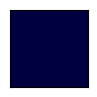

In [113]:
from matplotlib.colors import ListedColormap

def _heatmap(
    heatmap,
    title="",
    logit=None,
    reference_heatmap=None,
    total_score=None,
    grid_steps=4,
    fontsize=None,
):
    """Plot heatmap; this is adapted from https://git.tu-berlin.de/gmontavon/lrp-tutorial/-/blob/main/utils.py

    Args:
        heatmap np.array(h, w):
        reference_heatmap (np.array(h, w), optional): used for calculating normalization values. Defaults to None.
        total_score (float, optional): used for normalizing scores. Defaults to None.
    """
    assert len(heatmap.shape) == 2

    if reference_heatmap is None:
        reference_heatmap = heatmap

    assert len(reference_heatmap.shape) == 2

    b = np.abs(reference_heatmap).max()

    my_cmap = plt.cm.seismic(np.arange(plt.cm.seismic.N))
    my_cmap[:, 0:3] *= 0.85
    my_cmap = ListedColormap(my_cmap)

    sum_Ri = np.sum(heatmap)

    plt.xticks([])
    plt.yticks([])
    plt.imshow(heatmap, cmap=my_cmap, vmin=-b, vmax=b)
plt.figure(figsize=(1, 2))
_heatmap(np.zeros((224, 224)))

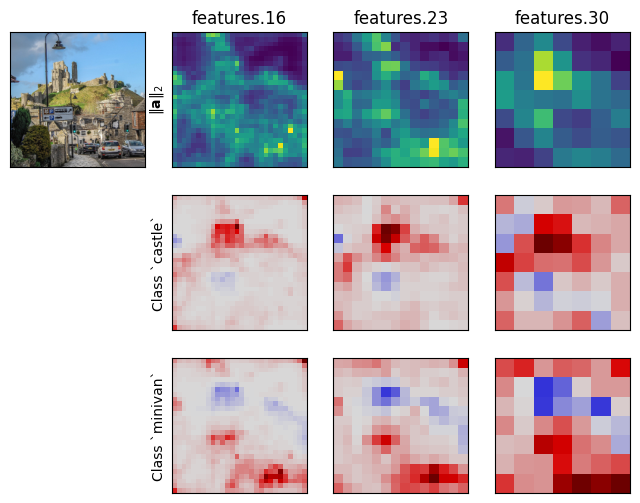

In [120]:
def ano():
    ncols = len(arr_layers) + 1
    nrows = 3
    plt.figure(figsize=(2*ncols, 2*nrows))
    plt.subplot(nrows, ncols, 1); plt.xticks([]); plt.yticks([])
    plt.imshow(img)

    for ix, layer in enumerate(arr_layers):
        plt.subplot(nrows, ncols, ix+2)
        plt.title(f"{layer}")
        if ix == 0:
            plt.ylabel("$\| \mathbf{a} \|_2$")
        output = np.linalg.norm(arr_outputs[ix].squeeze().detach().numpy(), axis=0)
        plt.imshow(output); plt.xticks([]); plt.yticks([])
    
    
    for cix, (label, class_ix) in enumerate([
        ("castle", 483), 
#         ("street_sign", 919),
        ("minivan", 656)
    ]):
    
        arr_relevances = explain_and_intercept(
            model,
            ts_img.unsqueeze(0),
            class_ix=class_ix,
        )
        
        for ix, _ in enumerate(arr_layers):
   
            plt.subplot(nrows, ncols, (cix+1)*ncols + ix+2)
            if ix == 0:
                plt.ylabel(f"Class `{label}`")
            
            hm = arr_relevances[ix]
            _heatmap(hm)
            
ano()